# HANC with heterogeneous discount factors

**Table of contents**<a id='toc0_'></a>
- 1. [Setup](#toc1_)
- 2. [Steady state](#toc2_)
- 3. [MPC](#toc3_)
- 4. [Calibrate the dispersion of discount factors](#toc4_)
- 5. [Wealth distribution](#toc5_)

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

**Exercise 1:** the HANC model with three types of households, $\beta_i\in\{\beta-\delta^{\beta},\beta,\beta+\delta^{\beta}\}$, each one third of the population. Find $\delta^{\beta}$ such that the mean MPC is 0.27, while keeping $K/Y=16$.

What changed relative to `0_HANC`:

1. `HANCModel.py`: `par.Nfix = 3`, the parameters `par.beta_mean` and `par.beta_delta`, and `par.beta_grid` is allocated in `allocate()`.
1. `steady_state.py`: `prepare_hh_ss` fills `par.beta_grid` and gives each type one third of the initial distribution. `find_ss` is the $\beta$ method from the lecture: $\alpha$, $\Gamma$ and $\delta$ in closed form from the targets, then a root-finder on `par.beta_mean`.
1. `household_problem.py`: a loop over the fixed types, each with its own `par.beta_grid[i_fix]`.

## 1. <a id='toc1_'></a>[Setup](#toc0_)

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

from HANCModel import HANCModelClass

plt.rcParams.update({"axes.grid" : True, "grid.color": "black", "grid.alpha":"0.25", "grid.linestyle": "--"})
plt.rcParams.update({'font.size': 14})

In [2]:
model = HANCModelClass(name='baseline')
par = model.par
ss = model.ss

## 2. <a id='toc2_'></a>[Steady state](#toc0_)

Find the steady state with `model.find_ss()`, then look at `par.beta_mean` and `par.beta_grid`.

In [3]:
model.find_ss()
print(f'beta_mean = {par.beta_mean:.4f}')
print(f'beta_grid = {par.beta_grid}')

beta_mean = 0.8861
beta_grid = [0.78608697 0.88608697 0.98608697]


The calibration targets, at the quarterly frequency:

- $Y=1$, a normalization, pins down $\Gamma$
- $K/Y=16$, an annual wealth-to-output ratio of 4, pins down $\beta$
- $r=0.05/4$, a 5% annual interest rate, pins down $\delta$
- $wL/Y=2/3$, the labor share, pins down $\alpha$

In [4]:
print(f'Y = {ss.Y:.4f}')
print(f'K/Y = {ss.K/ss.Y:.4f}')
print(f'r = {ss.r:.4f}')
print(f'w*L/Y = {ss.w*ss.L/ss.Y:.4f}')
print(f'clearing_A = {ss.clearing_A:.2e}, clearing_Y = {ss.clearing_Y:.2e}')

Y = 1.0000
K/Y = 16.0000
r = 0.0125
w*L/Y = 0.6667
clearing_A = -7.09e-09, clearing_Y = 1.37e-08


In [5]:
model.info(ss=True)

settings:
 par.py_hh = True
 par.py_blocks = True
 par.full_z_trans = False
 par.warnings = True
 par.T = 500

households:
 grids_hh: [a]
 pols_hh: [a]
 inputs_hh: [r,w]
 inputs_hh_z: []
 outputs_hh: [a,c]
 intertemps_hh: [vbeg_a]

aggregate:
 shocks: []
 unknowns: []
 targets: []

blocks (inputs -> outputs):
 production_firm: [] -> [Gamma=0.40,K=16.00,L=1.00,rK=0.02,w=0.67,Y=1.00]
 mutual_fund: [K=16.00,rK=0.02] -> [A=16.00,r=0.01]
 hh: [r=0.01,w=0.67] -> [A_hh=16.00,C_hh=0.87]
 market_clearing: [A=16.00,A_hh=16.00,L=1.00,Y=1.00,C_hh=0.87,K=16.00] -> [L_hh=1.00,I=0.13,clearing_A=-0.00,clearing_L=0.00,clearing_Y=0.00]


## 3. <a id='toc3_'></a>[MPC](#toc0_)

In [6]:
def calc_MPC(par,ss):
    """ MPC out of cash-on-hand from the slope of the consumption function """

    MPC = np.zeros(ss.D.shape)
    dc = ss.c[:,:,1:]-ss.c[:,:,:-1]
    dm = (1+ss.r)*(par.a_grid[1:]-par.a_grid[:-1])
    MPC[:,:,:-1] = dc/dm
    MPC[:,:,-1] = MPC[:,:,-2]

    return MPC

In [7]:
MPC = calc_MPC(par,ss)

print(f'mean MPC: {np.sum(MPC*ss.D):.3f}')
for i_fix in range(par.Nfix):
    MPC_type = np.sum(MPC[i_fix]*ss.D[i_fix])/np.sum(ss.D[i_fix])
    print(f'beta = {par.beta_grid[i_fix]:.3f}: mean MPC = {MPC_type:.3f}, share of wealth = {np.sum(ss.a[i_fix]*ss.D[i_fix])/ss.A_hh:.3f}')

mean MPC: 0.442
beta = 0.786: mean MPC = 0.828, share of wealth = 0.002
beta = 0.886: mean MPC = 0.477, share of wealth = 0.014
beta = 0.986: mean MPC = 0.020, share of wealth = 0.984


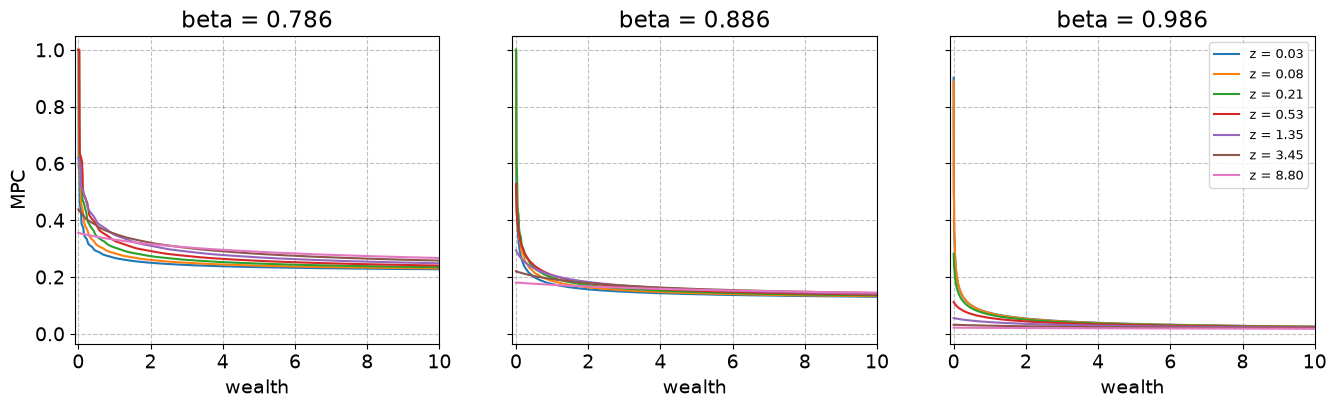

In [8]:
fig, axes = plt.subplots(1,par.Nfix,figsize=(16,4),sharey=True)
for i_fix, ax in enumerate(axes):
    ax.plot(par.a_grid,MPC[i_fix].T)
    ax.set_xlim(-0.1,10)
    ax.set_title(f'beta = {par.beta_grid[i_fix]:.3f}')
    ax.set_xlabel('wealth')
axes[0].set_ylabel('MPC')
axes[-1].legend([f'z = {z:.2f}' for z in par.z_grid],fontsize=9)
plt.show()

**Question:** Why do the impatient households have a high MPC? Who holds the wealth?

## 4. <a id='toc4_'></a>[Calibrate the dispersion of discount factors](#toc0_)

The mean MPC depends on how far apart the discount factors are. For each guess on `par.beta_delta` we must solve for the steady state again, so that $K/Y=16$ still holds: a root-finder around a root-finder.

In [9]:
def calib_obj(beta_delta,model):
    """ distance between the mean MPC and its target for a guess on beta_delta """

    model.par.beta_delta = beta_delta
    model.find_ss()

    mean_MPC = np.sum(calc_MPC(model.par,model.ss)*model.ss.D)
    print(f'beta_delta = {beta_delta:.4f}: mean MPC = {mean_MPC:.4f}')

    return mean_MPC-0.27

In [10]:
model_calib = model.copy()
optimize.brentq(calib_obj,0.01,0.1,args=(model_calib,),xtol=1e-8,rtol=1e-8)

beta_delta = 0.0100: mean MPC = 0.0701


beta_delta = 0.1000: mean MPC = 0.4417


beta_delta = 0.0584: mean MPC = 0.2867


beta_delta = 0.0543: mean MPC = 0.2704


beta_delta = 0.0542: mean MPC = 0.2700


beta_delta = 0.0542: mean MPC = 0.2700


beta_delta = 0.0542: mean MPC = 0.2700


beta_delta = 0.0542: mean MPC = 0.2700


0.05418695828006041

In [11]:
par_calib = model_calib.par
ss_calib = model_calib.ss

print(f'beta_delta = {par_calib.beta_delta:.4f}')
print(f'beta_grid = {par_calib.beta_grid}')
print(f'r = {ss_calib.r*100:.2f} %, K/Y = {ss_calib.K/ss_calib.Y:.2f}')

beta_delta = 0.0542
beta_grid = [0.87763338 0.93182033 0.98600728]
r = 1.25 %, K/Y = 16.00


## 5. <a id='toc5_'></a>[Wealth distribution](#toc0_)

Compute the wealth shares and compare them to the data, as in the lecture notebook. How did the distribution of wealth change?

In [12]:
def get_share(D,a_grid,perc_bottom=0.0,perc_top=1.0):
    """ share of total wealth held between two percentiles of the wealth distribution """

    cdf = D.cumsum()
    wealth_cdf = (a_grid*D).cumsum()
    tot_wealth = (a_grid*D).sum()

    wealth_bottom = 0.0 if perc_bottom == 0.0 else np.interp(perc_bottom,cdf,wealth_cdf)
    wealth_top = tot_wealth if perc_top == 1.0 else np.interp(perc_top,cdf,wealth_cdf)

    return (wealth_top-wealth_bottom)/tot_wealth

In [13]:
Da = np.sum(ss_calib.D,axis=(0,1))

brackets = [(0.0,0.5),(0.5,0.9),(0.9,1.0),(0.99,1.0),(0.999,1.0),(0.9999,1.0)]
wealth_shares = np.array([get_share(Da,par_calib.a_grid,perc_bottom,perc_top) for perc_bottom,perc_top in brackets])*100

df = pd.read_csv('../wealth_psz.csv')
df = df[df['Year'] == 2019].drop(columns='Year')
df['value'] = df['value']*100
df['Model'] = wealth_shares
df = df.rename(columns={'value': 'Data PSZ'})
df = pd.pivot_table(df,columns='Quantile',values=['Data PSZ','Model'])
df = df[['Bottom 50%','Middle 40%','Top 10%','Top 1%','Top 0.1%','Top 0.01%']]

print(df.round(0))

Quantile  Bottom 50%  Middle 40%  Top 10%  Top 1%  Top 0.1%  Top 0.01%
Data PSZ         0.0        28.0     71.0    35.0      18.0        9.0
Model            1.0        42.0     57.0    10.0       1.0        0.0


We have more inequality than before, but struggle to match the very top.